In [36]:
# Please execute/shift-return this cell everytime you run the notebook.  Don't edit it. 
from notebook import * 

Done loading notebook! We're good to go!


# Q1 (20 points, 10 for each sub question)

1.  Assume that your computer can perform 4 double-precision floating-point
operations per clock cycle when the operands are stored in registers. Additionally,
accessing an operand from memory incurs a delay of 100 cycles for reading or
writing. The clock frequency of your computer is 2 GHz.

- How long will it take for your computer to complete the algorithms dgemm0 and
dgemm1 respectively, for n=1000? Please provide the answer in seconds.

- How much time is spent on reading/writing operands from/to memory for
dgemm0 and dgemm1 respectively, when n=1000? Please provide the answer in
seconds.

## Hint:

1. If less than 4 floating-point operations are executed continuously, they also
takes 1 cycle.
2. floating points are usually stored in the memory. When they are read, they
are loaded into registers. When they are written, they are stored into
memory.
3. We assume integer calculations take no time; no parallelism is considered in
this case.

## Q1 (a answer 

inner loop of dgemm0 takes 3 read from memory and 1 write to the memory, suppose C[i*n+j] += A[i*n+k] * B[k*n+j] first calculate i*n+j, i*n+k, k*n+j, since we assume integer calculations takes no time, these instructions time is ignored , then load A[i*n+k] and  B[k*n+j], C[i*n+j] into register, takes 3*100 cycles. then do a float multiply A[i*n+k] * B[k*n+j], then do a float add of C[i*n+j]+A[i*n+k] * B[k*n+j], since we assume we take 4 float operations in 1 cycle, it take 1 cycles. then we need to store the result back into memory, which take 100 cycles.

so the operation takes $ 300+1+100=401 $ cycles.

$$ 1000^3 * 401 / (2*10^9) =200.5 $$

###  it take for my computer to complete the algorithms for dgemm0 of  200.5 seconds

the memory operations takes $$ 1000^3 * 400 / (2*10^9) = 200.0 $$

### 200.0 seconds is spent on reading/writing operands from/to memory for dgemm0

second  loop j  of dgemm1 first load C[i*n+j] into register, which takes 100cycles.
then third loop k takes 2 read from memory and 1 write to the memory,
for  r += A[i*n+k] * B[k*n+j] first calculate  i*n+k, k*n+j, since we assume integer calculations takes no time, these instructions time is ignored , then load A[i*n+k] and  B[k*n+j] into register, takes 2*100 cycles. then do a float multiply A[i*n+k] * B[k*n+j], then do a float add of r+A[i*n+k] * B[k*n+j], since we assume we take 4 float operations in 1 cycle, it take 1 cycles. then we need to store the result back into register, which take 1 cycle.
then we goes into second loop j, We need to store the register value back to C[i*n+j] in the memory, which takes 100cycles.

for loop j, it takes $ n*n*(100+100)  = 1000*1000*(200) = 200000000 $ cycles.

for loop k, it takes $ n*n*n*(2*100+1+1) = 1000*1000*1000*(202)= 202000000000 $ cycles.

$$ (200000000+202000000000) / (2*10^9) =101.1 $$

### it take for my computer to complete the algorithms for dgemm1 of   101.1 seconds

the memory operations takes $$ (1000^3 * 200 + 1000^2*200) / (2*10^9) = 100.1 $$

### 100.1 seconds is spent on reading/writing operands from/to memory for dgemm1


In [4]:
compare([do_render_code("dgemm0.c", show="dgemm0"),
        do_render_code("dgemm1.c", show="dgemm1")])

In [5]:
!python bench1.py > bench1.csv

In [6]:
display_mono(render_csv("bench1.csv"))

,index,func,size,padding,time,correctness
0,0,dgemm0,64,1,0.000993s,1
1,1,dgemm1,64,1,0.000648s,1
2,2,dgemm0,128,1,0.008805s,1
3,3,dgemm1,128,1,0.005495s,1
4,4,dgemm0,256,1,0.119891s,1
5,5,dgemm1,256,1,0.048847s,1
6,6,dgemm0,512,1,1.165579s,1
7,7,dgemm1,512,1,0.765333s,1
8,8,dgemm0,1024,1,9.147360s,1
9,9,dgemm1,1024,1,5.879810s,1


##  Q1 (b answer 

### Verify the correctness of your implementation and report the time spent in the triple loop for each algorithm.

the running time is showing above, correctness column is whether the program is correct, if it is correct, the value is 1

### Calculate the performance of each algorithm in Gflops. Performance is typically measured as the number of floating-point operations executed per second. A performance of 1 Gflops corresponds to 10^9 floating-point operations per second.

for dgemm0 and dgemm1, each time a loop execution does 2 floating point operations.so

$$Gflops = \frac{n^3*2}{time}*\frac{1}{10^9} $$


please scoll down to see the results.

In [20]:
import pandas as pd
import numpy as np
file_path = 'bench1.csv'
data = pd.read_csv(file_path)
data.columns = data.columns.str.strip()
data.drop('padding', axis=1, inplace=True)
data.drop('correctness', axis=1, inplace=True)
data['time'] = data['time'].str.replace('s', '').astype(float)
data['Gflops'] = (data['size'] ** 3 * 2) / data['time'] / 1e9

,func,size,time,Gflops
0,dgemm0,64,0.000993,0.527984
1,dgemm1,64,0.000648,0.809086
2,dgemm0,128,0.008805,0.476355
3,dgemm1,128,0.005495,0.763295
4,dgemm0,256,0.119891,0.279874
5,dgemm1,256,0.048847,0.686929
6,dgemm0,512,1.165579,0.230302
7,dgemm1,512,0.765333,0.350743
8,dgemm0,1024,9.147360,0.234765
9,dgemm1,1024,5.879810,0.365230


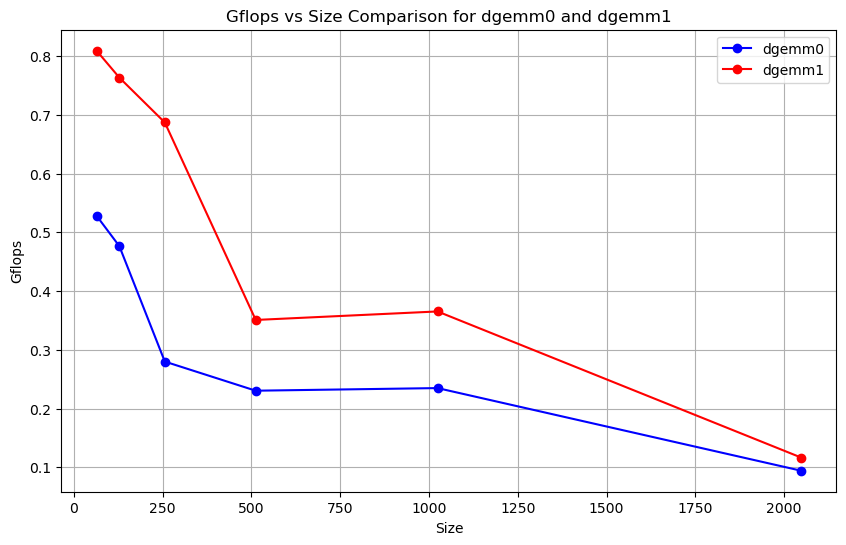

In [21]:
dgemm0_data = data[data['func'] == 'dgemm0']
dgemm1_data = data[data['func'] == 'dgemm1']

plt.figure(figsize=(10, 6))
plt.plot(dgemm0_data['size'], dgemm0_data['Gflops'], marker='o', linestyle='-', color='b', label='dgemm0')
plt.plot(dgemm1_data['size'], dgemm1_data['Gflops'], marker='o', linestyle='-', color='r', label='dgemm1')

plt.xlabel('Size')
plt.ylabel('Gflops')
plt.title('Gflops vs Size Comparison for dgemm0 and dgemm1')
plt.legend()
plt.grid(True)

display(data)
plt.show()

from the chart, We can see as matrix grows larger and larger, both dgemm0 and dgemm1 slows down, I think that's because cached data is populated out.

# Q2 (20 points)

Implement dgemm2 using 12 registers as outlined on Page 10 of optimizing-
sequential-programs.pptx. (shown in the figure below)
    
- Test dgemm2 on hpc-001 with n=64, 128, 256, 512, 1024, 2048.
-  Report the execution time and calculate the performance of your code in Gflops.

### let's analysis how many float point operations in dgemm2

in the loop k, c00 += a00*b00 + a01*b10, a00*b00 and a01*b10 are 2 multiplies, a00*b00 + a01*b10 is 1 addition,
c00 = c00 + a00*b00 + a01*b10 is another 1 addition, and it repeat 4 times,  so there are 16 float point operations in one loop iteration.

the loop will run $ (n/2)^3 $ times, so total float ops is $ (n/2)^3* 16 $

so the total $Gflops = \frac{(n/2)^3*16}{time}*\frac{1}{10^9} $


In [38]:
render_code("dgemm2.c", show="dgemm2")

// dgemm2.c:1-28 (28 lines)
void dgemm2(double *C,double *A,double *B,int n)
{
    int i,j,k;
    for(int i=0;i<n;i+=2){
        for(int j=0;j<n;j+=2){
            register double c00,c01,c10,c11;
            register int t1,t2;
            t1 = i*n+j;
            t2 = t1+n;//t2 = (i+1)*n+j;
            c00=C[t1];c01=C[t1+1];
            c10=C[t2];c11=C[t2+1];
            for(int k=0;k<n;k+=2){
                register int ta = i*n+k; register int tta = ta+n; register int tb = k*n+j; register int ttb = tb+n;
                register double a00 = A[ta]; register double a01 = A[ta+1]; register double a10 = A[tta]; register double a11 = A[tta+1];
                register double b00 = B[tb]; register double b01 = B[tb+1]; register double b10 = B[ttb]; register double b11 = B[ttb+1];
                c00 += a00*b00 + a01*b10;
                c01 += a00*b01 + a01*b11;
                c10 += a10*b00 + a11*b10;
                c11 += a10*b01 + a11*b11;
            }
            C[t1]=c00;
            C[t1+1]=c01;
            C[t2]=c10;
            C[t2+1]=c11;
        }
    }
     
}

### below is the correctness and running time of dgemm2

In [32]:
!python bench2.py > bench2.csv
display_mono(render_csv("bench2.csv"))

,index,func,size,padding,time,correctness
0,0,dgemm2,64,1,0.000245s,1
1,1,dgemm2,128,1,0.002010s,1
2,2,dgemm2,256,1,0.017457s,1
3,3,dgemm2,512,1,0.232088s,1
4,4,dgemm2,1024,1,1.743581s,1
5,5,dgemm2,2048,1,39.610940s,1


### below is the GFLOPS calculated and a chart comparing with dgemm0 dgemm1

,func,size,time,Gflops
0,dgemm2,64,0.000245,2.139951
1,dgemm2,128,0.002010,2.086718
2,dgemm2,256,0.017457,1.922119
3,dgemm2,512,0.232088,1.156611
4,dgemm2,1024,1.743581,1.231651
5,dgemm2,2048,39.610940,0.433715


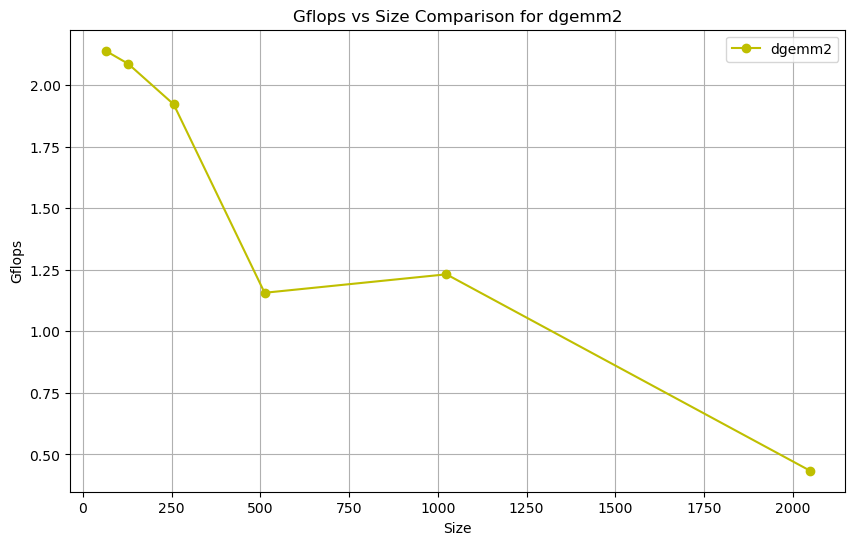

In [4]:
import pandas as pd
import numpy as np
def cleanning(df):
    df.columns = df.columns.str.strip()
    df = df.drop('padding', axis=1)
    df = df.drop('correctness', axis=1)
    df['time'] = df['time'].str.replace('s', '').astype(float)
    return df

data2 = cleanning(pd.read_csv('bench2.csv'))
data2['Gflops'] = ( (data2['size']/2) ** 3 * 16) / data2['time'] / 1e9
dgemm2_data = data2
plt.figure(figsize=(10, 6))
plt.plot(dgemm2_data['size'], dgemm2_data['Gflops'], marker='o', linestyle='-', color='y', label='dgemm2')
plt.xlabel('Size')
plt.ylabel('Gflops')
plt.title('Gflops vs Size Comparison for dgemm2')
plt.legend()
plt.grid(True)
display(data2)
plt.show()

# Q3 (10 points)

Assuming you have 16 floating-point registers, implement dgemm3 with the
maximum possible register reuse.
- Test dgemm3 on hpc-001 with n=64, 128, 256, 512, 1024, 2048.
- Report the execution time and calculate the performance of your code in Gflops.
- Compare the performance of dgemm3 with dgemm0~2.

In [42]:
!python bench3.py > bench31.csv
display_mono(render_csv("bench31.csv"))

make: 'main' is up to date.
n=512
time=0.238852s


Let's see my baseline version, using 8 register 

In [43]:
render_code("dgemm3v1.c", show="dgemm3")

// dgemm3v1.c:1-25 (25 lines)
void dgemm3(double *C,double *A,double *B,int n)
{
int i,j,k;
for(int i=0;i<n;i+=2){
     for(int j=0;j<n;j+=2){
          register double c00,c01,c10,c11;
          register int t1,t2;
          t1 = i*n+j;t2 = t1+n;
          c00=C[t1];c01=C[t1+1];c10=C[t2];c11=C[t2+1];
          for(int k=0;k<n;k+=2){
               register int ta = i*n+k; register int tta = ta+n; register int tb = k*n+j; register int ttb = tb+n;
               register double a00 = A[ta]; register double a10 = A[tta]; register double b00 = B[tb]; register double b01 = B[tb+1]; 

               c00 += a00*b00 ; c01 += a00*b01 ; c10 += a10*b00 ; c11 += a10*b01 ;

               a00 = A[ta+1]; a10 = A[tta+1]; b00 = B[ttb]; b01 = B[ttb+1];

               c00 += a00*b00 ; c01 += a00*b01 ; c10 += a10*b00 ; c11 += a10*b01 ;
          }
          C[t1]=c00;
          C[t1+1]=c01;
          C[t2]=c10;
          C[t2+1]=c11;
     }
}

In [45]:
!python bench3.py > bench31.csv
display_mono(render_csv("bench31.csv"))

,index,func,size,padding,time,correctness
0,0,dgemm3,64,1,0.000240s,1
1,1,dgemm3,128,1,0.002027s,1
2,2,dgemm3,256,1,0.017506s,1
3,3,dgemm3,512,1,0.232377s,1
4,4,dgemm3,1024,1,1.778989s,1
5,5,dgemm3,2048,1,48.332170s,1


it seems using 8 register is slower than 12 register version

### Let's try more register version

My idea is to unroll the loop k twice, so it will use more registers

this v2 version ** add 4 more registers **.

In [47]:
render_code("dgemm3v2.c", show="dgemm3")

// dgemm3v2.c:1-41 (41 lines)
void dgemm3(double *C,double *A,double *B,int n)
{
int i,j,k;
for(int i=0;i<n;i+=2){
     for(int j=0;j<n;j+=4){
          register double c00,c01,c10,c11;
          register double c20,c21,c30,c31;
          register int t1,t2;
          t1 = i*n+j;t2 = (i+1)*n+j;
          c00=C[t1];  c01=C[t1+1];c10=C[t2];c11=C[t2+1];
          c20=C[t1+2];c21=C[t1+3];c30=C[t2+2];c31=C[t2+3];
          for(int k=0;k<n;k+=2){
               register int ta = i*n+k; register int tta = ta+n; register int tb = k*n+j; register int ttb = tb+n;
               register double a00 = A[ta]; register double a10 = A[tta]; register double b00 = B[tb]; register double b01 = B[tb+1]; 

               c00 += a00*b00 ; c01 += a00*b01 ; c10 += a10*b00 ; c11 += a10*b01 ;

               a00 = A[ta+1]; a10 = A[tta+1]; b00 = B[ttb]; b01 = B[ttb+1];

               c00 += a00*b00 ; c01 += a00*b01 ; c10 += a10*b00 ; c11 += a10*b01 ;

               ta = i*n+k;  tta = ta+n;  tb = k*n+j+2;  ttb = tb+n;
               a00 = A[ta]; a10 = A[tta];
               b00 = B[tb]; b01 = B[tb+1]; 

               c20 += a00*b00 ; c21 += a00*b01 ; c30 += a10*b00 ; c31 += a10*b01 ;

               a00 = A[ta+1]; a10 = A[tta+1]; b00 = B[ttb]; b01 = B[ttb+1];

               c20 += a00*b00 ; c21 += a00*b01 ; c30 += a10*b00 ; c31 += a10*b01 ;
          }
          C[t1]=c00;
          C[t1+1]=c01;
          C[t1+2]=c20;
          C[t1+3]=c21;
          C[t2]=c10;
          C[t2+1]=c11;
          C[t2+2]=c30;
          C[t2+3]=c31;
     }
}

In [48]:
!python bench3.py > bench32.csv
display_mono(render_csv("bench32.csv"))

,index,func,size,padding,time,correctness
0,0,dgemm3,64,1,0.000234s,1
1,1,dgemm3,128,1,0.001931s,1
2,2,dgemm3,256,1,0.016846s,1
3,3,dgemm3,512,1,0.207502s,1
4,4,dgemm3,1024,1,1.677752s,1
5,5,dgemm3,2048,1,33.655922s,1


### yes, this 12 float register version is 1.5x faster than the baseline version, and even faster than dgemm2

### let's try adding register to 16 floating register.

In [3]:
render_code("dgemm3v3.c", show="dgemm3")

// dgemm3v3.c:1-34 (34 lines)
void dgemm3(double *C,double *A,double *B,int n)
{
int i,j,k;
for(int i=0;i<n;i+=2){
     for(int j=0;j<n;j+=4){
          register double c00,c01,c10,c11;
          register double c20,c21,c30,c31;
          register int t1,t2;
          t1 = i*n+j;t2 = (i+1)*n+j;
          c00=C[t1];  c01=C[t1+1];c10=C[t2];c11=C[t2+1];
          c20=C[t1+2];c21=C[t1+3];c30=C[t2+2];c31=C[t2+3];
          for(int k=0;k<n;k+=2){
               register int ta = i*n+k; register int tta = ta+n; register int tb = k*n+j; register int ttb = tb+n;
               register int tb2 = tb+2,  ttb2 = tb2+n;
               register double a00 = A[ta], a10 = A[tta], b00 = B[tb], b01 = B[tb+1];
               register double a01 = A[ta+1], a11 = A[tta+1];
               register double B_tb2 =B[tb+2];register double B_tb21 =B[tb+3];
               c00 += a00*b00 ; c01 += a00*b01 ; c10 += a10*b00 ; c11 += a10*b01 ;
               b00 = B[ttb]; b01 = B[ttb+1];
               c00 += a01*b00 ; c01 += a01*b01 ; c10 += a11*b00 ; c11 += a11*b01 ;
               c20 += a00*B_tb2 ; c21 += a00*B_tb21 ; c30 += a10*B_tb2 ; c31 += a10*B_tb21 ;
               b00 = B[ttb2]; b01 = B[ttb2+1];
               c20 += a01*b00 ; c21 += a01*b01 ; c30 += a11*b00 ; c31 += a11*b01 ;
          }
          C[t1]=c00;
          C[t1+1]=c01;
          C[t1+2]=c20;
          C[t1+3]=c21;
          C[t2]=c10;
          C[t2+1]=c11;
          C[t2+2]=c30;
          C[t2+3]=c31;
     }
}

In [10]:
!python bench3.py > bench33.csv
display_mono(render_csv("bench33.csv"))

,index,func,size,padding,time,correctness
0,0,dgemm3,64,1,0.000187s,1
1,1,dgemm3,128,1,0.001631s,1
2,2,dgemm3,256,1,0.015751s,1
3,3,dgemm3,512,1,0.177594s,1
4,4,dgemm3,1024,1,1.362993s,1
5,5,dgemm3,2048,1,26.301165s,1


### runs faster

using 3x3 matrix

#### using 15 register

In [37]:
render_code("dgemm3.c", show="dgemm3")

// dgemm3.c:1-61 (61 lines)
void dgemm3(double *C,double *A,double *B,int n_)
{
int i;
register int j,k;
register const int n=n_;
const int STRIDE = 3;
register double c00,c01,c02, c10,c11,c12,c20,c21,c22;
register double a00, a10,a20, b00, b01, b02;
register int t,tt,ttt;
for(i=0;i<n;i+=STRIDE){
     for(j=0;j<n;j+=STRIDE){
          t = i*n+j;
          c00=C[t];c01=C[t+1];c02=C[t+2];
          tt= t+n;
          c10=C[tt];c11=C[tt+1];c12=C[tt+2];
          ttt=tt+n;
          c20=C[ttt];c21=C[ttt+1];c22=C[ttt+2];
          for(k=0;k<n;k+=STRIDE){
               register int ta = i*n+k; register int tb = k*n+j; 
               register int tta = ta+n;register int ttb = tb+n;
               register int ttta = tta+n;register int tttb = ttb+n;
               // Load elements of A,B into temporary variables
               a00 = A[ta]; a10 = A[tta]; a20 = A[ttta];
               b00 = B[tb]; b01 = B[tb+1]; b02 = B[tb+2];
                
               //below uses register a00 a10 a20  b00 b01 b02  
               c00 += a00 * b00;c01 += a00 * b01;c02 += a00 * b02;
               c10 += a10 * b00;c11 += a10 * b01;c12 += a10 * b02 ;
               c20 += a20 * b00 ;c21 += a20 * b01;c22 += a20 * b02;
               
               //after this line a00,a10,a20,b00,b01,b02 will not be used anymore
               // we need to load a01 a02 a11 a12 a21 a22 b10 b11 b12 b20 b21 b22 12 register, but 7 available
               //if we select a01,a11,a21 we need b10 b11 b12
               // so we load a00=A01, a10=A11, a20=A21, b00=B10 b01=B11 b02=B12
               a00 = A[ta+1]; a10 = A[tta+1]; a20 = A[ttta+1];
               b00 = B[ttb];  b01 = B[ttb+1]; b02 = B[ttb+2];
               c00 += a00 * b00;c01 += a00 * b01 ;c02 += a00 * b02 ;
               c10 += a10 * b00 ;c11 += a10 * b01;c12 += a10 * b02;
               c20 += a20 * b00;c21 += a20 * b01; c22 += a20 * b02;
               //after this line, a00,a10,a20, b00,b01,b02, b10,b11,b12 is not being used anymore
               // we still need a02 a12 a22 b20 b21 b22
               // so we load a00=A02, a10=A12, a20=A22, b00=B20 b01=B21 b02=B22
               a00 = A[ta+2];a10 = A[tta+2];a20 = A[ttta+2];
               b00 = B[tttb]; b01 = B[tttb+1]; b02 = B[tttb+2];
               c00 += a00 * b00;
               c01 += a00 * b01;
               c02 += a00 * b02;
               
               c10 += a10 * b00;
               c11 += a10 * b01;
               c12 += a10 * b02;
               
               c20 += a20 * b00;
               c21 += a20 * b01;
               c22 += a20 * b02;
          }
          C[t]=c00;C[t+1]=c01;C[t+2]=c02;
          C[tt]=c10;C[tt+1]=c11;C[tt+2]=c12;
          C[ttt]=c20;C[ttt+1]=c21;C[ttt+2]=c22;
     }
}

In [39]:
!python bench3.py > bench34.csv

In [40]:
display_mono(render_csv("bench34.csv"))

,index,func,size,padding,time,correctness
0,0,dgemm3,66,3,0.000184s,1
1,1,dgemm3,129,3,0.001330s,1
2,2,dgemm3,258,3,0.011536s,1
3,3,dgemm3,513,3,0.124626s,1
4,4,dgemm3,1026,3,0.818681s,1
5,5,dgemm3,2049,3,6.693280s,1


# Q3 Answer


let me show the code first.


In [16]:
render_code("dgemm3.c", show="dgemm3")

// dgemm3.c:1-36 (36 lines)
void dgemm3(double *C,double *A,double *B,int n)
{
int i,j,k;
for(int i=0;i<n;i+=2){
     for(int j=0;j<n;j+=4){
          register double c00,c01,c10,c11;
          register double c20,c21,c30,c31;
          register int t1,t2;
          t1 = i*n+j;t2 = t1+n;
          c00=C[t1];
          c01=C[t1+1];c20=C[t1+2];c21=C[t1+3];
          c10=C[t2];
          c11=C[t2+1];c30=C[t2+2];c31=C[t2+3];
          
          for(int k=0;k<n;k+=2){
               register int ta = i*n+k; register int tta = ta+n; register int tb = k*n+j; register int ttb = tb+n;
               register double a00 = A[ta],a01 = A[ta+1], a10 = A[tta],a11 = A[tta+1];
               register double b00 = B[tb], b01 = B[tb+1];
               c00 += a00*b00 ; c01 += a00*b01 ; c10 += a10*b00 ; c11 += a10*b01 ;
               b00 = B[ttb]; b01 = B[ttb+1];
               c00 += a01*b00 ; c01 += a01*b01 ; c10 += a11*b00 ; c11 += a11*b01 ;
               b00 = B[tb+2]; b01 = B[tb+3];
               c20 += a00*b00 ; c21 += a00*b01 ; c30 += a10*b00 ; c31 += a10*b01 ;
               b00 = B[ttb+2]; b01 = B[ttb+3];
               c20 += a01*b00 ; c21 += a01*b01 ; c30 += a11*b00 ; c31 += a11*b01 ;
          }
          C[t1]=c00;
          C[t1+1]=c01;
          C[t1+2]=c20;
          C[t1+3]=c21;
          C[t2]=c10;
          C[t2+1]=c11;
          C[t2+2]=c30;
          C[t2+3]=c31;
     }
}

first analysis the GFLOPS, in the loop k.

$ c00 += a00*b00 ; c01 += a00*b01 ; c10 += a10*b00 ; c11 += a10*b01 $

this line has 2*4=8 float operations.

$ c00 += a01*b00 ; c01 += a01*b01 ; c10 += a11*b00 ; c11 += a11*b01 $

this line has 2*4=8 float operations.

$ c20 += a00*b00 ; c21 += a00*b01 ; c30 += a10*b00 ; c31 += a10*b01 $

this line has 2*4=8 float operations.

$ c20 += a01*b00 ; c21 += a01*b01 ; c30 += a11*b00 ; c31 += a11*b01 $

this line has 2*4=8 float operations.

so in the loop k, there are 8*4=32 float operations.

the loop will run $ n/2 * n/4 * n/2 $ times

so the total $Gflops = \frac{\frac{n}{2} * \frac{n}{4} * \frac{n}{2} * 32}{time}*\frac{1}{10^9} $

simplify it,  $Gflops = \frac{2 * n^3}{time} *\frac{1}{10^9}$

,func,size,time,Gflops
0,dgemm3,64,0.000187,2.803679
1,dgemm3,128,0.001631,2.571615
2,dgemm3,256,0.015751,2.130305
3,dgemm3,512,0.177594,1.511512
4,dgemm3,1024,1.362993,1.575565
5,dgemm3,2048,26.301165,0.653198


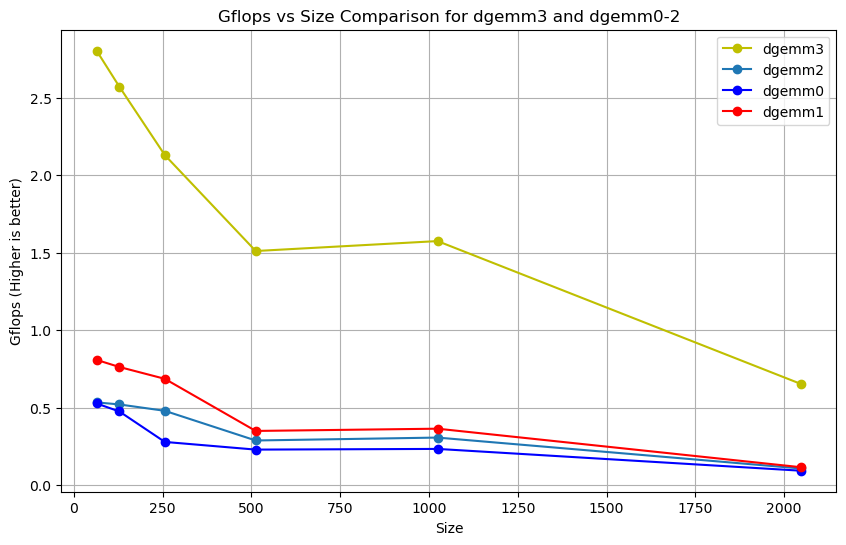

In [31]:
import pandas as pd
import numpy as np
def cleanning(df):
    df.columns = df.columns.str.strip()
    df = df.drop('padding', axis=1)
    df = df.drop('correctness', axis=1)
    df['time'] = df['time'].str.replace('s', '').astype(float)
    return df

data3 = cleanning(pd.read_csv('bench33.csv'))
data3['Gflops'] = ( (data3['size']) ** 3 * 2) / data3['time'] / 1e9
dgemm3_data = data3
plt.figure(figsize=(10, 6))
plt.plot(dgemm3_data['size'], dgemm3_data['Gflops'], marker='o', linestyle='-', color='y', label='dgemm3')
plt.plot(dgemm2_data['size'], dgemm2_data['Gflops'], marker='o', linestyle='-', label='dgemm2')
plt.plot(dgemm0_data['size'], dgemm0_data['Gflops'], marker='o', linestyle='-', color='b', label='dgemm0')
plt.plot(dgemm1_data['size'], dgemm1_data['Gflops'], marker='o', linestyle='-', color='r', label='dgemm1')

plt.xlabel('Size')
plt.ylabel('Gflops (Higher is better)')
plt.title('Gflops vs Size Comparison for dgemm3 and dgemm0-2')
plt.legend()
plt.grid(True)
display(data3)
plt.show()

You can see,dgemm3 out perform all the other versions

### Let draw the executing time chart too.

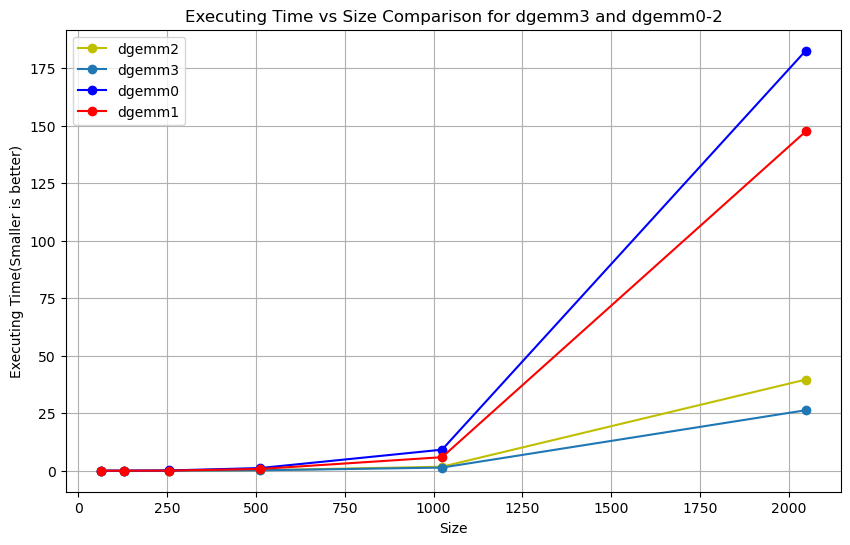

In [30]:
import pandas as pd
import numpy as np
def cleanning(df):
    df.columns = df.columns.str.strip()
    df = df.drop('padding', axis=1)
    df = df.drop('correctness', axis=1)
    df['time'] = df['time'].str.replace('s', '').astype(float)
    return df

et01 = cleanning(pd.read_csv('bench1.csv'))
et2  = cleanning(pd.read_csv('bench2.csv'))
et3  = cleanning(pd.read_csv('bench33.csv'))
et0 = et01[data['func'] == 'dgemm0']
et1 = et01[data['func'] == 'dgemm1']

plt.figure(figsize=(10, 6))
plt.plot(et2['size'], et2['time'], marker='o', linestyle='-', color='y', label='dgemm2')
plt.plot(et3['size'], et3['time'], marker='o', linestyle='-', label='dgemm3')
plt.plot(et0['size'], et0['time'], marker='o', linestyle='-', color='b', label='dgemm0')
plt.plot(et1['size'], et1['time'], marker='o', linestyle='-', color='r', label='dgemm1')

plt.xlabel('Size')
plt.ylabel('Executing Time(Smaller is better)')
plt.title('Executing Time vs Size Comparison for dgemm3 and dgemm0-2')
plt.legend()
plt.grid(True)
plt.show()

when the matrix size is smaller than 512, the four programs amost runs at the same duration,but after matrix size 1024, dgemm3 out perform all the other versions

# Q4 (15 points)

Assuming a cache with 60 lines, each capable of holding 10 double values, is utilized
in your program. You implement a simple GEMM (C=C+A*B) with single cache reuse
(as shown in the figure below), and you test different looping configurations: ijk, ikj,
jik, jki, kij, kji. Please answer the following questions.


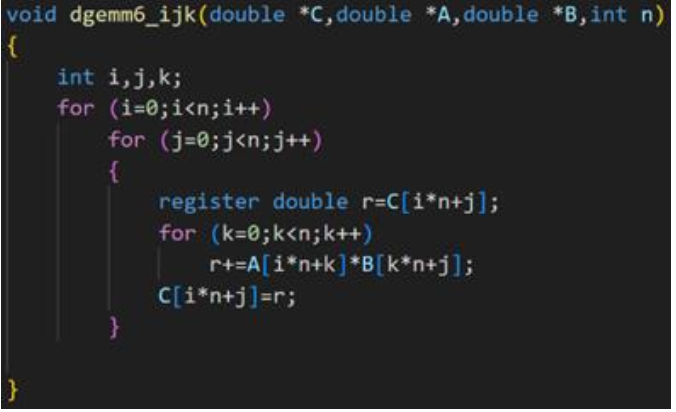


When the matrix size is 10*10, calculate the number of cache reads required for
matrix elements in A, B, and C respectively. Additionally, determine how many of
these reads will incur a cache miss. Please calculate the read cache miss rate for
matrices A, B, C, as well as the overall read cache miss rate for the GEMM
operation. Please provide a complete calculation process in the report and
present your results in a format similar to the table below.


Hint:
1. The cache contains only the elements from the matrices.
2. The cache strategy employed is LRUF (Least Recently Used First).
3. Each matrix is represented as a one-dimensional array in row-major order.

# Q4.1 answer

## kij

### **Detailed Calculation Process**

1. **Initialization**:
   - **Cache starts empty**.
   - Matrices are loaded as needed, with entire cache lines (10 doubles) loaded on a miss.

2. **Access Patterns and Cache Loading**:
   - **Matrix A**:
     - Accessed sequentially by rows.
     - First access to each row causes a cache miss; entire row loaded.
   - **Matrix B**:
     - Accessed by columns, but stored in rows.
     - Initial accesses to each row cause cache misses; rows remain in cache due to capacity.
   - **Matrix C**:
     - Accessed sequentially by rows.
     - First access to each row causes a cache miss; entire row loaded.

3. **Cache Capacity Considerations**:
   - **Total Cache Lines Used**:
     - 10 for A, 10 for B, 10 for C: Total 30 cache lines.
   - **Available Cache Lines**:
     - 60 lines; no cache evictions occur.
   - **Cache Strategy Impact**:
     - LRUF ensures that once a cache line is loaded, it remains unless capacity is exceeded.

4. **Cache Misses and Hits**:
   - **First Accesses**:
     - Cause cache misses for each new row in A and C, and each new row in B during initial loading.
   - **Subsequent Accesses**:
     - Cache hits due to data remaining in cache and spatial locality for A and C.

5. **Final Calculations**:
   - **Cache Misses**:
     - Determined by the number of first accesses to new cache lines.
   - **Cache Miss Rates**:
     - Calculated as the ratio of cache misses to total reads for each matrix.

### **Cache Access Analysis**

#### **Total Reads Calculation**

- **Matrix A**:
  - Accessed inside the loops over **i**, **j**, and **k**.
  - **Total Reads**: $ n^3 = 10^3 = 1000 $ reads.

- **Matrix B**:
  - Accessed similarly to A.
  - **Total Reads**: $ n^3 = 10^3 = 1000 $ reads.

- **Matrix C**:
  - Read once at the beginning of the inner loops over **i** and **j**.
  - **Total Reads**: $ n^2 = 10^2 = 100 $ reads.

#### **Cache Miss Calculation**

##### **Matrix A**

- **Access Pattern**:
  - For each **i** and **j**, we access the entire row **i** of A.
  - Elements $ A[i \times n + 0..9] $ are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ A[i \times n + 0] $, a cache miss occurs, and the entire row (10 elements) is loaded into a cache line.
  - Subsequent accesses to $ A[i \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **i** from 0 to 9).

##### **Matrix B**

- **Access Pattern**:
  - For each **i** and **j**, we access column **j** of B.
  - Elements $ B[k \times n + j] $ for $ k = 0..9 $ are accessed.
  - Stored in row-major order, so accessing columns leads to poor spatial locality.

- **Cache Behavior**:
  - Initial accesses to each $ B[k \times n + 0..9] $ result in cache misses.
  - Once loaded, these cache lines remain in cache due to sufficient capacity and LRUF policy.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **k** from 0 to 9).

##### **Matrix C**

- **Access Pattern**:
  - For each **i** and **j**, $ C[i \times n + j] $ is accessed.
  - Elements \( C[i \times n + 0..9] \) are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ C[i \times n + 0] $, a cache miss occurs, loading the entire row into cache.
  - Subsequent accesses to $ C[i \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **i** from 0 to 9).

#### **Cache Miss Rates**

- **Matrix A**:
  - **Total Reads**: 1000
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{1000} \times 100\% = 1\% $

- **Matrix B**:
  - **Total Reads**: 1000
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{1000} \times 100\% = 1\% $

- **Matrix C**:
  - **Total Reads**: 100
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{100} \times 100\% = 10\% $

#### **Overall GEMM Operation**

- **Total Reads**: 1000 (A) + 1000 (B) + 100 (C) = **2100 reads**
- **Total Cache Misses**: 10 (A) + 10 (B) + 10 (C) = **30 misses**
- **Overall Cache Miss Rate**:
  - $ \frac{30}{2100} \times 100\% \approx 1.43\% $

---

### **Summary Table**

| Matrix | Total Reads | Cache Misses | Cache Miss Rate |
|--------|-------------|--------------|-----------------|
| A      | 1000        | 10           | 1%              |
| B      | 1000        | 10           | 1%              |
| C      | 100         | 10           | 10%             |
| **Overall** | **2100**   | **30**      | **~1.43%**      |

---



---

### **Conclusion**

The cache read requirements and miss rates for matrices A, B, and C have been thoroughly analyzed, considering the cache's characteristics and the program's access patterns. The overall cache miss rate for the GEMM operation is approximately **1.43%**, indicating efficient cache utilization given the cache's ability to hold all required data without evictions.

## ikj

### **Detailed Calculation Process**

1. **Initialization**:
   - **Cache starts empty**.
   - Matrices are loaded as needed, with entire cache lines (10 doubles) loaded on a miss.

2. **Access Patterns and Cache Loading**:
   - **Matrix A**:
     - Accessed sequentially by rows.
     - First access to each row causes a cache miss; entire row loaded.
   - **Matrix B**:
     - Accessed sequentially by rows.
     - First access to each row causes a cache miss; entire row loaded.
   - **Matrix C**:
     - Accessed by columns, but stored in rows.
     - Initial accesses to each row cause cache misses; rows remain in cache due to capacity.

4. **Cache Capacity Considerations**:
   - **Total Cache Lines Used**:
     - 10 for A, 10 for B, 10 for C: Total 30 cache lines.
   - **Available Cache Lines**:
     - 60 lines; no cache evictions occur.
   - **Cache Strategy Impact**:
     - LRUF ensures that once a cache line is loaded, it remains unless capacity is exceeded.


### **Cache Access Analysis**

#### **Total Reads Calculation**

- **Matrix A**:
  - Read once at the beginning of the inner loop over **i** and **k**.
  -  **Total Reads**: $ n*2 = 100 $.

- **Matrix B**:
  - Accessed insider the loops over  **i**, **j**, and **k**.
  - **Total Reads**: $ n^3 = 10^3 = 1000 $ reads.

- **Matrix C**:
  -- Accessed insider the loops over  **i**, **j**, and **k**.
  - **Total Reads**: $ n^3 = 10^3 = 1000 $ reads.

#### **Cache Miss Calculation**

##### **Matrix A**

- **Access Pattern**:
  - For each **i** and **k**, we access the entire row **i** of A.
  - Elements $ A[i \times n + 0..9] $ are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ A[i \times n + 0] $, a cache miss occurs, and the entire row (10 elements) is loaded into a cache line.
  - Subsequent accesses to $ A[i \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **i** from 0 to 9).

##### **Matrix B**

- **Access Pattern**:
  - For each **i** and **k**, we access the entire row **k** of B.
  - Elements $ B[i \times n + 0..9] $ are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ A[k \times n + 0] $, a cache miss occurs, and the entire row (10 elements) is loaded into a cache line.
  - Subsequent accesses to $ A[k \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **k** from 0 to 9).

##### **Matrix C**

- **Access Pattern**:
  - For each **i** and **k**, $ C[i \times n + j] $ is accessed.
  - Elements \( C[k \times n + 0..9] \) are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ C[i \times n + 0] $, a cache miss occurs, loading the entire row into cache.
  - Subsequent accesses to $ C[i \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **i** from 0 to 9).

#### **Cache Miss Rates**
- **Matrix A**:
  - **Total Reads**: 100
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{100} \times 100\% = 10\% $

- **Matrix B**:
  - **Total Reads**: 1000
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{1000} \times 100\% = 1\% $

- **Matrix C**:
  - **Total Reads**: 1000
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{1000} \times 100\% = 1\% $



#### **Overall GEMM Operation**

- **Total Reads**: 1000 (A) + 1000 (B) + 100 (C) = **2100 reads**
- **Total Cache Misses**: 10 (A) + 10 (B) + 10 (C) = **30 misses**
- **Overall Cache Miss Rate**:
  - $ \frac{30}{2100} \times 100\% \approx 1.43\% $

---

### **Summary Table**

| Matrix | Total Reads | Cache Misses | Cache Miss Rate |
|--------|-------------|--------------|-----------------|
| A      | 100         | 10           | 10%             |
| B      | 1000        | 10           | 1%              |
| C      | 1000        | 10           | 1%              |
| **Overall** | **2100**   | **30**      | **~1.43%**      |

---

## jik

### **Detailed Calculation Process**

1. **Initialization**:
   - **Cache starts empty**.
   - Matrices are loaded as needed, with entire cache lines (10 doubles) loaded on a miss.

2. **Access Patterns and Cache Loading**:
   - **Matrix A**:
     - Accessed sequentially by rows.
     - First access to each row causes a cache miss; entire row loaded.rows remain in cache due to capacity.
   - **Matrix B**:
     - Accessed sequentially by rows.
     - Initial accesses to each row cause cache misses; rows remain in cache due to capacity.
   - **Matrix C**:
     - Accessed sequentially by rows.
     - First access to each row causes a cache miss; entire row loaded.rows remain in cache due to capacity.

3. **Cache Capacity Considerations**:
   - **Total Cache Lines Used**:
     - 10 for A, 10 for B, 10 for C: Total 30 cache lines.
   - **Available Cache Lines**:
     - 60 lines; no cache evictions occur.
   - **Cache Strategy Impact**:
     - LRUF ensures that once a cache line is loaded, it remains unless capacity is exceeded.
     

### **Cache Access Analysis**

#### **Total Reads Calculation**
- **Matrix A**:
  -- Accessed insider the loops over  **j**, **i**, and **k**.
  - **Total Reads**: $ n^3 = 10^3 = 1000 $ reads.
- **Matrix B**:
  - Accessed insider the loops over  **j**, **i**, and **k**.
  - **Total Reads**: $ n^3 = 10^3 = 1000 $ reads.

- **Matrix C**:
  - Read once at the beginning of the inner loop over **j** and **i**.
  -  **Total Reads**: $ n*2 = 100 $.

#### **Cache Miss Calculation**

##### **Matrix A**

- **Access Pattern**:
  - For each **j** and **i**, we access the entire row **i** of A.
  - Elements $ A[i \times n + 0..9] $ are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ A[i \times n + 0] $, a cache miss occurs, and the entire row (10 elements) is loaded into a cache line.
  - Subsequent accesses to $ A[i \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **i** from 0 to 9).


##### **Matrix B**

- **Access Pattern**:
  - For each **j** and **i**, $ B[k \times n + j] $ is accessed.
  - Elements \( B[k \times n + 0..9] \) are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ B[i \times n + 0] $, a cache miss occurs, loading the entire row into cache.
  - Subsequent accesses to $ B[i \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **i** from 0 to 9).
 
##### **Matrix C**

- **Access Pattern**:
  - For each **j** and **i**, $ C[i \times n + j] $ is accessed.
  - Elements \( C[i \times n + 0..9] \) are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ C[i \times n + 0] $, a cache miss occurs, loading the entire row into cache.
  - Subsequent accesses to $ C[i \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **i** from 0 to 9).

#### **Cache Miss Rates**

- **Matrix A**:
  - **Total Reads**: 1000
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{1000} \times 100\% = 1\% $

- **Matrix B**:
  - **Total Reads**: 1000
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{1000} \times 100\% = 1\% $

- **Matrix C**:
  - **Total Reads**: 100
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{100} \times 100\% = 10\% $

#### **Overall GEMM Operation**

- **Total Reads**: 1000 (A) + 1000 (B) + 100 (C) = **2100 reads**
- **Total Cache Misses**: 10 (A) + 10 (B) + 10 (C) = **30 misses**
- **Overall Cache Miss Rate**:
  - $ \frac{30}{2100} \times 100\% \approx 1.43\% $

---

### **Summary Table**

| Matrix | Total Reads | Cache Misses | Cache Miss Rate |
|--------|-------------|--------------|-----------------|
| A      | 1000        | 10           | 1%              |
| B      | 1000        | 10           | 1%              |
| C      | 100         | 10           | 10%             |
| **Overall** | **2100**   | **30**      | **~1.43%**      |

---

## jki

### **Detailed Calculation Process**

1. **Initialization**:
   - **Cache starts empty**.
   - Matrices are loaded as needed, with entire cache lines (10 doubles) loaded on a miss.

2. **Access Patterns and Cache Loading**:
   - **Matrix A**:
     - Accessed by columns, but stored in rows.
     -  Initial accesses to each row cause cache misses; rows remain in cache due to capacity.
   - **Matrix B**:
     - Accessed by columns, but stored in rows.
     - Initial accesses to each row cause cache misses; rows remain in cache due to capacity.
   - **Matrix C**:
     - Accessed by columns, but stored in rows.
     - Initial accesses to each row cause cache misses; rows remain in cache due to capacity.

3. **Cache Capacity Considerations**:
   - **Total Cache Lines Used**:
     - 10 for A, 10 for B, 10 for C: Total 30 cache lines.
   - **Available Cache Lines**:
     - 60 lines; no cache evictions occur.
   - **Cache Strategy Impact**:
     - LRUF ensures that once a cache line is loaded, it remains unless capacity is exceeded.

4. **Cache Misses and Hits**:
   - **First Accesses**:
     - Cause cache misses for each new row in A ,B and C.
   - **Subsequent Accesses**:
     - Cache hits due to data remaining in cache and A,B,C.

5. **Final Calculations**:
   - **Cache Misses**:
     - Determined by the number of first accesses to new cache lines.
   - **Cache Miss Rates**:
     - Calculated as the ratio of cache misses to total reads for each matrix.

### **Cache Access Analysis**

#### **Total Reads Calculation**

- **Matrix A**:
  - Accessed inside the loops over **j**, **k**, and **k**.
  - **Total Reads**: $ n^3 = 10^3 = 1000 $ reads.

- **Matrix B**:
  - Accessed by the first time inside the loops over **j** and **k**.
  - **Total Reads**: $ n^2 = 10^2 = 100 $ reads.

- **Matrix C**:
  - Accessed inside the loops over **j**, **k**, and **k**.
  - **Total Reads**: $ n^3 = 10^3 = 1000 $ reads.

#### **Cache Miss Calculation**

##### **Matrix A**

- **Access Pattern**:
  - For each **i** and **j**, we access the entire column **i** of A.
  - Elements $ A[i \times n + 0..9] $ are stored consecutively.

- **Cache Behavior**:
  - On the first access to $ A[i \times n + 0] $, a cache miss occurs, and the entire row (10 elements) is loaded into a cache line.
  - Subsequent accesses to $ A[i \times n + 1..9] $ are cache hits.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **i** from 0 to 9).

##### **Matrix B**

- **Access Pattern**:
  - For each **i** and **j**, we access column **j** of B.
  - Elements $ B[k \times n + j] $ for $ k = 0..9 $ are accessed.
  - Stored in row-major order, so accessing columns leads to poor spatial locality.

- **Cache Behavior**:
  - Initial accesses to each $ B[k \times n + 0..9] $ result in cache misses.
  - Once loaded, these cache lines remain in cache due to sufficient capacity and LRUF policy.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **k** from 0 to 9).

##### **Matrix C**

- **Access Pattern**:
  - For each **j** and **k**, we access column **i** of C.
  - Elements $ C[i \times n + j] $ for $ k = 0..9 $ are accessed.
  - Stored in row-major order, so accessing columns leads to poor spatial locality.

- **Cache Behavior**:
  - Initial accesses to each $ C[i \times n + 0..9] $ result in cache misses.
  - Once loaded, these cache lines remain in cache due to sufficient capacity and LRUF policy.

- **Cache Misses**:
  - **Total Misses**: 10 (once per row **k** from 0 to 9).

#### **Cache Miss Rates**

- **Matrix A**:
  - **Total Reads**: 1000
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{1000} \times 100\% = 1\% $

- **Matrix B**:
  - **Total Reads**: 100
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{100} \times 100\% = 10\% $

- **Matrix C**:
  - **Total Reads**: 1000
  - **Cache Misses**: 10
  - **Cache Miss Rate**: $ \frac{10}{1000} \times 100\% = 1\% $

#### **Overall GEMM Operation**

- **Total Reads**: 1000 (A) + 1000 (C) + 100 (B) = **2100 reads**
- **Total Cache Misses**: 10 (A) + 10 (B) + 10 (C) = **30 misses**
- **Overall Cache Miss Rate**:
  - $ \frac{30}{2100} \times 100\% \approx 1.43\% $

---

### **Summary Table**

| Matrix | Total Reads | Cache Misses | Cache Miss Rate |
|--------|-------------|--------------|-----------------|
| A      | 1000        | 10           | 1%              |
| B      | 100        | 10           | 10%              |
| C      | 1009         | 10           | 1%             |
| **Overall** | **2100**   | **30**      | **~1.43%**      |

---

## kij

### **Detailed Calculation Process**

1. **Initialization**:
   - **Cache starts empty**.
   - Matrices are loaded as needed, with entire cache lines (10 doubles) loaded on a miss.

2. **Access Patterns and Cache Loading**:
   - **Matrix A**:
     - Accessed sequentially by rows.
     - First access to each row causes a cache miss; entire row loaded.
   - **Matrix B**:
     - Accessed by columns, but stored in rows.
     - Initial accesses to each row cause cache misses; rows remain in cache due to capacity.
   - **Matrix C**:
     - Accessed sequentially by rows.
     - First access to each row causes a cache miss; entire row loaded.

3. **Cache Capacity Considerations**:
   - **Total Cache Lines Used**:
     - 10 for A, 10 for B, 10 for C: Total 30 cache lines.
   - **Available Cache Lines**:
     - 60 lines; no cache evictions occur.
   - **Cache Strategy Impact**:
     - LRUF ensures that once a cache line is loaded, it remains unless capacity is exceeded.

4. **Cache Misses and Hits**:
   - **First Accesses**:
     - Cause cache misses for each new row in A and C, and each new row in B during initial loading.
   - **Subsequent Accesses**:
     - Cache hits due to data remaining in cache and spatial locality for A and C.

5. **Final Calculations**:
   - **Cache Misses**:
     - Determined by the number of first accesses to new cache lines.
   - **Cache Miss Rates**:
     - Calculated as the ratio of cache misses to total reads for each matrix.

In [10]:
render_code("dgemm6_ijk.c", show="dgemm6_ijk")

// dgemm6_ijk.c:1-14 (14 lines)
void dgemm6_ijk(double *C,double *A,double *B,int n)
{
     int i,j,k;
     for(i=0;i<n;i++){
         for(j=0;j<n;j++){
             register double r = C[i*n+j];
             for(k=0;k<n;k++){
                 r+=A[i*n+k]*B[k*n+j];
             }
             C[i*n+j]=r;
         }
     }

}

|Loop Order|A # of read |A # of miss|	B # of read|	B # of miss|	C # of read	|C # of miss	|Overall Miss Rate|
|---:|:-------------|:-----------|:-----------|:------|:-----------|:-----------|:-----------|
| ijk | 1000  | 10   | 1000   | 10     |100 | 10 | 0.05714285714285714 |
| ikj | 100  | 10   | 1000   | 10     |1000 | 10 | 0.05714285714285714 |
| jik | 1000  | 10   | 1000   | 10     |100 | 10 | 0.05714285714285714 |
| jki | 1000  | 10   | 100   | 10     |1000 | 10 | 0.05714285714285714 |
| kij | 1000  | 10   | 1000   | 10     |100 | 10 | 0.05714285714285714 |
| kji | 1000  | 10   | 1000   | 10     |100 | 10 | 0.05714285714285714 |

# Q4.2

## ijk


- **Reads from \( A \):** $ (1 \times 10^4)^3 = 1 \times 10^{12} $
- **Reads from \( B \):** $ 1 \times 10^{12} $
- **Reads from \( C \):** $ (1 \times 10^4)^2 = 1 \times 10^8 $

---

### **Cache Miss Calculations**

#### **Matrix \( A \):**

- **Access Pattern:** Sequential access to each row $ A[i][k] $ for fixed $ i $.
- **Cache Misses per $ (i, j) $:** 1000 misses.
- **Total Cache Misses for $ A $:**
  - **Total $ (i, j) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 1000 \times 1 \times 10^8 = 1 \times 10^{11} $

#### **Matrix \( B \):**

- **Access Pattern:** Strided access to $ B[k][j] $ as $ k $ varies, with a stride of $ n = 10000 $.
- **Cache Lines Needed per $ (i, j) $ Pair:**
  - Each access is to a new cache line due to large stride.
  - **Cache Misses per $ (i, j) $:** $ n = 10000 $ misses.
- **Total Cache Misses for $ B $:**
  - **Total $ (i, j) $ Pairs:** $ 1 \times 10^8 $
  - **Total Misses:** $ 10000 \times 1 \times 10^8 = 1 \times 10^{12} $

#### **Matrix \( C \):**

- **Access Pattern:** Sequential access to each element $ C[i][j] $.
- **Cache Lines Needed per Row:** $ \frac{10000}{10} = 1000 $ lines.
- **Cache Misses per Row:**
  - Similar to $ A $, cannot fit an entire row in cache.
  - **Cache Misses per Row:** 1000 misses.
- **Total Cache Misses for $ C $:**
  - **Total Rows:** $ n = 10000 $
  - **Total Misses:** $ 1000 \times 10000 = 1 \times 10^{7} $

---

### **Overall Read Cache Miss Rate**

- **Total Cache Reads:**
  - $ \text{Reads from } A + \text{Reads from } B + \text{Reads from } C = 1 \times 10^{12} + 1 \times 10^{12} + 1 \times 10^{8} \approx 2 \times 10^{12} $
- **Total Cache Misses:**
  - $ \text{Misses from } A + \text{Misses from } B + \text{Misses from } C = 1 \times 10^{11} + 1 \times 10^{12} + 1 \times 10^{7} \approx 1.1 \times 10^{12} $
- **Overall Miss Rate:**
  - $ \frac{1.1 \times 10^{12}}{2 \times 10^{12}} = 0.55 $ or **55%**
 
## ikj


- **Reads from \( C \):** $ (1 \times 10^4)^3 = 1 \times 10^{12} $
- **Reads from \( B \):** $ 1 \times 10^{12} $
- **Reads from \( A \):** $ (1 \times 10^4)^2 = 1 \times 10^8 $

---

### **Cache Miss Calculations**

#### **Matrix \( A \):**

- **Access Pattern:** Sequential access to each element $ A[i][j] $.
- **Cache Lines Needed per Row:** $ \frac{10000}{10} = 1000 $ lines.
- **Cache Misses per Row:**
  - cannot fit an entire row in cache.
  - **Cache Misses per Row:** 1000 misses.
- **Total Cache Misses for $ A $:**
  - **Total Rows:** $ n = 10000 $
  - **Total Misses:** $ 1000 \times 10000 = 1 \times 10^{7} $


#### **Matrix \( B \):**

- **Access Pattern:** Sequential access to each row $ B[k][j] $ for fixed $ k $.
- **Cache Misses per $ (i, k) $:** 1000 misses.
- **Total Cache Misses for $ B $:**
  - **Total $ (i, k) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 1000 \times 1 \times 10^8 = 1 \times 10^{11} $


#### **Matrix \( C \):**

- **Access Pattern:** Sequential access to each element $ C[i][j] $.
- **Cache Lines Needed per Row:** $ \frac{10000}{10} = 1000 $ lines.
- **Cache Misses per Row:**
  - cannot fit an entire row in cache.
  - **Cache Misses per Row:** 1000 misses.
- **Total Cache Misses for $ C $:**
  - **Total Rows:** $ n = 10000 $
  - **Total Misses:** $ 1000 \times 10000 = 1 \times 10^{7} $

---

### **Overall Read Cache Miss Rate**

- **Total Cache Reads:**
  - $ \text{Reads from } A + \text{Reads from } B + \text{Reads from } C = 1 \times 10^{12} + 1 \times 10^{12} + 1 \times 10^{8} \approx 2 \times 10^{12} $
- **Total Cache Misses:**
  - $ \text{Misses from } A + \text{Misses from } B + \text{Misses from } C = 1 \times 10^{11} + 1 \times 10^{12} + 1 \times 10^{7} \approx 1.1 \times 10^{12} $
- **Overall Miss Rate:**
  - $ \frac{1.1 \times 10^{12}}{2 \times 10^{12}} = 0.55 $ or **55%**
 
## jik


- **Reads from \( A \):** $ (1 \times 10^4)^3 = 1 \times 10^{12} $
- **Reads from \( B \):** $ 1 \times 10^{12} $
- **Reads from \( C \):** $ (1 \times 10^4)^2 = 1 \times 10^8 $

---

### **Cache Miss Calculations**

#### **Matrix \( A \):**

- **Access Pattern:** Sequential access to each element $ A[i][k] $.
- **Cache Lines Needed per Row:** $ \frac{10000}{10} = 1000 $ lines.
- **Cache Misses per Row:**
  - cannot fit an entire row in cache.
  - **Cache Misses per Row:** 1000 misses.
- **Total Cache Misses for $ A $:**
  - **Total Rows:** $ n = 10000 $
  - **Total Misses:** $ 1000 \times 10^8 = 1 \times 10^{11} $


#### **Matrix \( B \):**

- **Access Pattern:** column access to each row $ B[k][j] $ for fixed $ j $.
- **Cache Misses per $ (i, j) $:** 10^4 misses.
- **Total Cache Misses for $ B $:**
  - **Total $ (i, k) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 10^4 \times 1 \times 10^8 = 1 \times 10^{12} $


#### **Matrix \( C \):**

- **Access Pattern:** column access to each element $ C[i][j] $.
- **Cache Lines Needed per Row:** $ \frac{10000}{10} = 1000 $ lines.
- **Cache Misses per $ (i, j) $:** 10^4 misses.
- **Total Cache Misses for $ C $:**
  - **Total Columns:** $ n = 10000 $
  - **Total Misses:** $ 10000 \times 10000 = 1 \times 10^{8} $

---

### **Overall Read Cache Miss Rate**

- **Total Cache Reads:**
  - $ \text{Reads from } A + \text{Reads from } B + \text{Reads from } C = 1 \times 10^{12} + 1 \times 10^{12} + 1 \times 10^{8} \approx 2 \times 10^{12} $
- **Total Cache Misses:**
  - $ \text{Misses from } A + \text{Misses from } B + \text{Misses from } C = 1 \times 10^{11} + 1 \times 10^{12} + 1 \times 10^{8} \approx 1.1 \times 10^{12} $
- **Overall Miss Rate:**
  - $ \frac{1.1 \times 10^{12}}{2 \times 10^{12}} = 0.55 $ or **55%**
 
## jki


- **Reads from \( A \):** $ (1 \times 10^4)^3 = 1 \times 10^{12} $
- **Reads from \( B \):** $ (1 \times 10^4)^2 = 1 \times 10^8 $
- **Reads from \( C \):** $ 1 \times 10^{12} $

---

### **Cache Miss Calculations**

#### **Matrix \( A \):**

- **Access Pattern:** column access to each row $ A[i][k] $ for fixed $ j $.
- **Cache Misses per $ (j,k) $:** 10^4 misses.
- **Total Cache Misses for $ B $:**
  - **Total $ (i, k) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 10^4 \times 1 \times 10^8 = 1 \times 10^{12} $

#### **Matrix \( B \):**

- **Access Pattern:** column access to each element $ B[k][j] $.
- **Cache Lines Needed per Row:** $ \frac{10000}{10} = 1000 $ lines.
- **Cache Misses per $ (j,k) $:** 10^4 misses.
- **Total Cache Misses for $ C $:**
  - **Total Columns:** $ n = 10000 $
  - **Total Misses:** $ 10000 \times 10000 = 1 \times 10^{8} $

#### **Matrix \( C \):**

- **Access Pattern:** column access to each row $ C[i][j] $ for fixed $ j $.
- **Cache Misses per $ (j,k) $:** 10^4 misses.
- **Total Cache Misses for $ B $:**
  - **Total $ (i, k) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 10^4 \times 1 \times 10^8 = 1 \times 10^{12} $

---

### **Overall Read Cache Miss Rate**

- **Total Cache Reads:**
  - $ \text{Reads from } A + \text{Reads from } B + \text{Reads from } C = 1 \times 10^{12} + 1 \times 10^{12} + 1 \times 10^{8} \approx 2 \times 10^{12} $
- **Total Cache Misses:**
  - $ \text{Misses from } A + \text{Misses from } B + \text{Misses from } C = 1 \times 10^{12} + 1 \times 10^{12} + 1 \times 10^{8} \approx 2 \times 10^{12} $
- **Overall Miss Rate:**
  - $ \frac{2 \times 10^{12}}{2 \times 10^{12}} = 1 $ or **100%**
 
---

## kij


- **Reads from \( A \):** $ (1 \times 10^4)^3 = 1 \times 10^{12} $
- **Reads from \( B \):** $ (1 \times 10^4)^2 = 1 \times 10^8 $
- **Reads from \( C \):** $ 1 \times 10^{12} $

---

### **Cache Miss Calculations**

#### **Matrix \( A \):**

- **Access Pattern:** column access to each row $ B[k][j] $ for fixed $ j $.
- **Cache Misses per $ (i, j) $:** 10^4 misses.
- **Total Cache Misses for $ B $:**
  - **Total $ (i, k) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 10^4 \times 1 \times 10^8 = 1 \times 10^{12} $



#### **Matrix \( B \):**

- **Access Pattern:** column access to each row $ B[k][j] $ for fixed $ j $.
- **Cache Misses per $ (i, j) $:** 10^4 misses.
- **Cache Misses per Row:**
  - Similar to $ A $, cannot fit an entire row in cache.
  - **Cache Misses per Row:** 1000 misses.
- **Total Cache Misses for $ B $:**
  - **Total Rows:** $ n = 10000 $
  - **Total Misses:** $ 1000 \times 10000 = 1 \times 10^{7} $


#### **Matrix \( C \):**

- **Access Pattern:** column access to each element $ C[i][j] $.
- **Cache Lines Needed per Row:** $ \frac{10000}{10} = 1000 $ lines.
- **Cache Misses per $ (i, j) $:** 10^4 misses.
- **Total Cache Misses for $ C $:**
  - **Total $ (i, k) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 10^4 \times 1 \times 10^8 = 1 \times 10^{12} $

## kji


- **Reads from \( A \):** $ (1 \times 10^4)^3 = 1 \times 10^{12} $
- **Reads from \( B \):** $ (1 \times 10^4)^2 = 1 \times 10^8 $
- **Reads from \( C \):** $ 1 \times 10^{12} $

---

### **Cache Miss Calculations**

#### **Matrix \( A \):**

- **Access Pattern:** column access to each row $ B[k][j] $ for fixed $ j $.
- **Cache Misses per $ (i, j) $:** 10^4 misses.
- **Total Cache Misses for $ B $:**
  - **Total $ (i, k) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 10^4 \times 1 \times 10^8 = 1 \times 10^{12} $



#### **Matrix \( B \):**

- **Access Pattern:** column access to each row $ B[k][j] $ for fixed $ j $.
- **Cache Misses per $ (i, j) $:** 10^4 misses.
- **Cache Misses per Row:**
  - Similar to $ A $, cannot fit an entire row in cache.
  - **Cache Misses per Row:** 1000 misses.
- **Total Cache Misses for $ B $:**
  - **Total Rows:** $ n = 10000 $
  - **Total Misses:** $ 1000 \times 10000 = 1 \times 10^{7} $


#### **Matrix \( C \):**

- **Access Pattern:** column access to each element $ C[i][j] $.
- **Cache Lines Needed per Row:** $ \frac{10000}{10} = 1000 $ lines.
- **Cache Misses per $ (i, j) $:** 10^4 misses.
- **Total Cache Misses for $ C $:**
  - **Total $ (i, k) $ Pairs:** $ n^2 = 1 \times 10^8 $
  - **Total Misses:** $ 10^4 \times 1 \times 10^8 = 1 \times 10^{12} $



|Loop Order|A # of read |A # of miss|	B # of read|	B # of miss|	C # of read	|C # of miss	|Overall Miss Rate|
|---:|:-------------|:-----------|:-----------|:------|:-----------|:-----------|:-----------|
| ijk | 10^12  | 10^11   | 10^12    | 10^12     | 10^8 | 10^7 | 55% |
| ikj | 10^12 | 10^11 | 10^12  | 10^12   | 10^12    | 10^12     | 55% |
| jik | 10^12  | 10^11   | 10^12    | 10^12     | 10^8 | 10^8 | 55% |
| jki | 10^12  | 10^12   | 10^12    | 10^12     | 10^8 | 10^8 | 100% | 
| kij | 10^12  | 10^12   | 10^8    | 10^2     | 10^8 | 10^7 | 55% |
| kji | 10^12  | 10^12   | 10^8    | 10^2     | 10^8 | 10^7 | 55% |

# Q5

you implement blocked GEMM algorithms with
single cache reuse and a block size of 10*10. You test 6 loop configurations where
iteration order inside the blocks is the same as that at the matrix level (i.e. the outer
3 loops follow the same order as the inner 3 loops。
Please answer the following questions.


When the matrix size is 10000*10000, calculate the number of reads and read
cache misses for all six loop orders. Please provide a complete calculation
process in the report.

---
# ijk

**Matrix Dimensions:**

- \(n = 10000\)
- **Number of Blocks per Dimension:** $ \frac{n}{\text{BLOCK\_SIZE}} = \frac{10000}{10} = 1000 $

**Loop Structure Analysis:**

- **Outer Loops:** Iterate over i,j,k in steps of 10 (block size), resulting in $ 1000 \times 1000 \times 1000 = 10^9 $  block iterations.
- **Inner Loops:** Within each block, iterate over $ii$, $jj$, and $kk$ in steps of 1.

**Total Cache Reads:**

1. **Matrix A:**
   - **Access Pattern:** For each block iteration, $A[ii \times n + kk]$ is accessed $10 \times 10 \times 10 = 1000$ times.
   - **Total Reads:** \(10^9 \text{ (blocks)} \times 1000 = 10^{12}\) reads.

2. **Matrix B:**
   - **Access Pattern:** For each block iteration, $B[kk \times n + jj]$ is accessed $10 \times 10 \times 10 = 1000$ times.
   - **Total Reads:** \(10^9 \times 1000 = 10^{12}\) reads.

3. **Matrix C:**
   - **Access Pattern:** For each block iteration, $C[ii \times n + jj]$ is accessed $10 \times 10 = 100$ times.
   - **Total Reads:** \(10^9 \times 100 = 10^{11}\) reads.

---

### 3. Determining Cache Misses for Each Matrix

**Cache Miss Analysis:**

1. **Matrix A:**
   - **Access Pattern:** Sequential access within a row allows each cache line to be loaded once per $ii$ per $k$-block.
   - **Cache Misses:**
     - **Per Block:** 10 cache lines (one for each ii.
     - **Total Misses:** $ 10^9 \text{ (blocks)} \times 10 = 10^{10} $ cache misses.

2. **Matrix B:**
   - **Access Pattern:** Non-sequential access across different rows leads to each access potentially mapping to a new cache line.
   - **Cache Misses:**
     - **Per Access:** Each $B[kk \times n + jj]$ likely maps to a distinct cache line.
     - **Total Misses:** $10^{12} $ cache misses (each access results in a miss).

3. **Matrix C:**
   - **Access Pattern:** Each $ C[ii \times n + jj] $is accessed once per k-block. With blocking, these elements can remain in the cache across k-blocks.
   - **Cache Misses:**
     - **Per $i,j$ Block:** 10 cache lines (one for each set of 10 \(C\) elements).
     - **Total Misses:**  $ 1000 \text{ (i blocks)} \times 1000 \text{ (j blocks)} \times 10 = 10^7 $ cache misses.

---

### 4. Calculating Cache Miss Rates

**Cache Miss Rate Formula:**
\[
\text{Cache Miss Rate} = \frac{\text{Number of Cache Misses}}{\text{Total Number of Cache Reads}} \times 100\%
\]

1. **Matrix A:**
   - **Miss Rate:** $\frac{10^{10}}{10^{12}} \times 100\% = 1\%$

2. **Matrix B:**
   - **Miss Rate:** $\frac{10^{12}}{10^{12}} \times 100\% = 100\%$

3. **Matrix C:**
   - **Miss Rate:** $\frac{10^{7}}{10^{11}} \times 100\% = 0.01\%$

---

### 5. Summarizing the Overall Cache Miss Rate

**Total Cache Reads:**
$
10^{12} \text{ (A)} + 10^{12} \text{ (B)} + 10^{11} \text{ (C)} = 2.1 \times 10^{12}
$

**Total Cache Misses:**
$
10^{10} \text{ (A)} + 10^{12} \text{ (B)} + 10^{7} \text{ (C)} = 1.0100001 \times 10^{12}
$

**Overall Cache Miss Rate:**
$
\frac{1.0100001 \times 10^{12}}{2.1 \times 10^{12}} \times 100\% \approx 48.1\%
$

# ikj

**Total Cache Reads:**

1. **Matrix C:**
   - **Access Pattern:** For each block iteration, $C[ii \times n + kk]$ is accessed $10 \times 10 \times 10 = 1000$ times.
   - **Total Reads:** \(10^9 \text{ (blocks)} \times 1000 = 10^{12}\) reads.

2. **Matrix B:**
   - **Access Pattern:** For each block iteration, $B[kk \times n + jj]$ is accessed $10 \times 10 \times 10 = 1000$ times.
   - **Total Reads:** \(10^9 \times 1000 = 10^{12}\) reads.

3. **Matrix A:**
   - **Access Pattern:** For each block iteration, $A[ii \times n + jj]$ is accessed $10 \times 10 = 100$ times.
   - **Total Reads:** \(10^9 \times 100 = 10^{11}\) reads.
   
**Cache Miss Analysis:**

1. **Matrix C:**
   - **Access Pattern:** Sequential access within a row allows each cache line to be loaded once per  block.
   - **Cache Misses:**
     - **Per Block:** 10 cache lines (one for each ii.
     - **Total Misses:** $ 10^9 \text{ (blocks)} \times 10 = 10^{10} $ cache misses.

1. **Matrix B:**
   - **Access Pattern:** Sequential access within a row allows each cache line to be loaded once per  block.
   - **Cache Misses:**
     - **Per Block:** 10 cache lines (one for each ii.
     - **Total Misses:** $ 10^9 \text{ (blocks)} \times 10 = 10^{10} $ cache misses.

3. **Matrix A:**
   - **Access Pattern:** Sequential access within a row allows each cache line to be loaded once per  block.
   - **Cache Misses:**
     - **Per   Block:** 10 cache lines (one for each set of 10 \(C\) elements).
     - **Total Misses:**  $ 1000 \text{ (i blocks)} \times 1000 \text{ (j blocks)} \times 10 = 10^7 $ cache misses.

|Loop Order|A # of read |A # of miss|	B # of read|	B # of miss|	C # of read	|C # of miss	|Overall Miss Rate|
|---:|:-------------|:-----------|:-----------|:------|:-----------|:-----------|:-----------|
| ijk-ijk | 10^12  | 10^10   | 10^12    | 10^12     | 10^11 | 10^7 | 48% |
| ikj-ikj | 10^11  | 10^7   | 10^12    | 10^10     | 10^12 | 10^10 | 1% |
| jik-jik | 10^12  | 10^8   | 10^12    | 10^8     | 10^11 | 10^11 | 4.7% |
| jki-jki | 10^12  | 10^12   | 10^12   | 10^12     | 10^11 | 10^11 | 100% |
| kij-kij | 10^12  | 10^11   | 10^12    | 10^11     | 10^11 | 10^11 | 14.2% |
| kji-kji | 10^12  | 10^11   | 10^11    | 10^10     | 10^12 | 10^11 | 10% |

# Q5.2

1. **A[0][0]:**
   - **Accessed When:**
     - `i = 0`, `ii = 0` (since `ii` ranges from `i` to `i+9`)
     - `k = 0`, `kk = 0` (since `kk` ranges from `k` to `k+9`)
     - For every `j` block (total of 1,000 blocks, as `n/BLOCK_SIZE = 10,000/10 = 1,000`)
     - Accessed 10 times per `j` block (once for each `jj` from `j` to `j+9`)
   - **Total Accesses:** 1,000 `j` blocks × 10 accesses per block = **10,000 accesses**
   - **Cache Behavior:**
     - Data accessed per `j` block: 120 unique elements
     - Cache can hold data for approximately 5 `j` blocks (600 cache slots / 120 elements per block)
     - **Cache Misses:** 1,000 `j` blocks / 5 ≈ **200 cache misses**

2. **A[17][21]:**
   - **Accessed When:**
     - `i = 10`, `ii = 17`
     - `k = 20`, `kk = 21`
     - For every `j` block (1,000 blocks)
     - Accessed 10 times per `j` block
   - **Total Accesses:** 1,000 `j` blocks × 10 accesses per block = **10,000 accesses**
   - **Cache Misses:** Similar to A[0][0], approximately **200 cache misses**

3. **B[100][130]:**
   - **Accessed When:**
     - `k = 100`, `kk = 100`
     - `j = 130`, `jj = 130`
     - For every `i` block (1,000 blocks)
     - Accessed once per `i` block
   - **Total Accesses:** 1,000 `i` blocks × 1 access per block = **1,000 accesses**
   - **Cache Behavior:**
     - Data accessed per `i` block: 21 unique elements
     - Cache can hold data for approximately 28 `i` blocks
     - **Cache Misses:** 1,000 `i` blocks / 28 ≈ **35 cache misses**

4. **B[101][134]:**
   - **Accessed When:**
     - `k = 100`, `kk = 101`
     - `j = 130`, `jj = 134`
     - For every `i` block
     - Accessed once per `i` block
   - **Cache Misses:** Approximately **35 cache misses** (same reasoning as B[100][130])

5. **C[68][90]:**
   - **Accessed When:**
     - `i = 60`, `ii = 68`
     - `j = 90`, `jj = 90`
     - For every `k` block (1,000 blocks)
     - Accessed 10 times per `k` block
   - **Total Accesses:** 1,000 `k` blocks × 10 accesses per block = **10,000 accesses**
   - **Cache Behavior:**
     - Data accessed per `k` block: 21 unique elements
     - Cache can hold data for approximately 28 `k` blocks
     - **Cache Misses:** 1,000 `k` blocks / 28 ≈ **35 cache misses**

6. **C[2000][1297]:**
   - **Accessed When:**
     - `i = 2000`, `ii = 2000`
     - `j = 1290`, `jj = 1297`
     - For every `k` block
     - Accessed 10 times per `k` block
   - **Cache Misses:** Approximately **35 cache misses** (same reasoning as C[68][90])


# Q6


this is the code I used to test blocked dgemm with different block size

In [4]:
!srun bench6.py | tee bench6.csv

^C
srun: interrupt (one more within 1 sec to abort)
srun: StepId=56930.0 task 0: running


In [6]:
import pandas as pd

df = pd.read_csv('benchQ6.csv')
df['time'] = df['time'].str.replace('s', '').astype(float)
df = df[df['size']==2048]
sorted_df = df.sort_values(by='time', ascending=True)
sorted_df


,func,size,padding,block_size,time,correctness
66,dgemm6_ijk2,2048,1,32,22.617605,1
68,dgemm6_jik2,2048,1,32,23.556135,1
72,dgemm6_ijk2,2048,1,64,23.805562,1
73,dgemm6_ikj2,2048,1,64,24.143920,1
60,dgemm6_ijk2,2048,1,16,24.224790,1
67,dgemm6_ikj2,2048,1,32,24.538563,1
74,dgemm6_jik2,2048,1,64,24.559656,1
62,dgemm6_jik2,2048,1,16,25.528180,1
70,dgemm6_kij2,2048,1,32,25.570335,1
61,dgemm6_ikj2,2048,1,16,25.637421,1


from the chart above, I think the best one is dgemm6_ijk2 with block size 32.

second is jik2 with block size 32.

I will start here and try to speed up it.

and it doesn't make sense kij ikj is slow, so I am going to imporve them too.

In [9]:
import os
BLOCK_SIZE = 32
MAT_SIZE = 512
os.system("gcc -DBLOCK_SIZE={} tester2.c -o bench6".format(BLOCK_SIZE))
os.system("./bench6 dgemm6_ijk2 {} 1".format(MAT_SIZE))
os.system("./bench6 dgemm6_ikj2 {} 1".format(MAT_SIZE))
os.system("./bench6 dgemm6_jik2 {} 1".format(MAT_SIZE))
os.system("./bench6 dgemm6_jki2 {} 1".format(MAT_SIZE))
os.system("./bench6 dgemm6_kij2 {} 1".format(MAT_SIZE))

In file included from include.c:17,
                 from tester2.c:1:
dgemm6_jik.c: In function ‘dgemm6_jik2’:
dgemm6_jik.c:24:28: warning: type defaults to ‘int’ in declaration of ‘iin’ [-Wimplicit-int]
             register const iin = ii*n;
                            ^~~


dgemm6_ijk2, 512, 1, 32, 0.347323s, 1
dgemm6_ikj2, 512, 1, 32, 0.364614s, 1
dgemm6_jik2, 512, 1, 32, 0.357969s, 1
dgemm6_jki2, 512, 1, 32, 1.079704s, 1
dgemm6_kij2, 512, 1, 32, 0.346241s, 1


0

In [13]:
!srun bench62.py

dgemm6_ijk2, 2048, 1, 16, 22.382504s, 1
dgemm6_ikj2, 2048, 1, 16, 22.410352s, 1
dgemm6_jik2, 2048, 1, 16, 23.568581s, 1
dgemm6_jki2, 2048, 1, 16, 65.511662s, 1
dgemm6_kij2, 2048, 1, 16, 22.260297s, 1
dgemm6_ijk2, 2048, 1, 32, 21.106790s, 1
dgemm6_ikj2, 2048, 1, 32, 21.741877s, 1
dgemm6_jik2, 2048, 1, 32, 21.699136s, 1
dgemm6_jki2, 2048, 1, 32, 70.018205s, 1
dgemm6_kij2, 2048, 1, 32, 20.909319s, 1
dgemm6_ijk2, 2048, 1, 64, 21.890237s, 1
dgemm6_ikj2, 2048, 1, 64, 21.680884s, 1
dgemm6_jik2, 2048, 1, 64, 22.533274s, 1
dgemm6_jki2, 2048, 1, 64, 70.689149s, 1
dgemm6_kij2, 2048, 1, 64, 21.819524s, 1


 all the programs are imporving, but this time kij with block size 32 wins, with time 20.9s

 and second fast became ijk2 with 21.1s

 kij is slow before because in the loop of k,i,j, ii*n is calculated 3 times, I improve it by using a register to store that value.
 

In [18]:
!gcc -DBLOCK_SIZE=32 tester2.c -o bench6
!srun bench6 dgemm6_kij2 2048 1

dgemm6_kij2, 2048, 1, 32, 14.086833s, 1


In [ ]:
!gcc -DBLOCK_SIZE=32 tester2.c -o bench6
!srun bench6 dgemm6_ijk2 2048 1

this time I improve them by using register for ii,kk,jj and also i,k,j.
it improves a lot. kij still runs faster than ijk.


# Q7

## first I made a ijk-ijk with 2x2 matrix reuse register verison

speed is 9.6s

## second I made a ijk-ijk with 3x3 matrix reuse register verison
with block 33 padding 33
speed is 6.8s

with block 33 padding 3
speed is 6.3s

with block 27 padding 3

speed is 6.1s

with block 24 padding 3
speed is 6.4s

so best configuration  for ijk-ijk with 3x3 matrix reuse register is block 27 padding 3

In [18]:
!gcc -DBLOCK_SIZE=33 tester2.c -o bench7
!srun bench7 dgemm7 2048 3

dgemm7, 2049, 3, 33, 6.301396s, 0


In [20]:
!gcc -DBLOCK_SIZE=27 tester2.c -o bench7
!srun bench7 dgemm7 2048 3

dgemm7, 2049, 3, 27, 6.167584s, 0


In [22]:
!gcc -DBLOCK_SIZE=24 tester2.c -o bench7
!srun bench7 dgemm7 2048 3

dgemm7, 2049, 3, 24, 6.421586s, 0


# try 4x4 version


In [24]:
!gcc -DBLOCK_SIZE=32 tester2.c -o bench8
!srun bench8 dgemm7 2048 1

dgemm7, 2048, 1, 32, 5.993495s, 1


In [25]:
!gcc -DBLOCK_SIZE=36 tester2.c -o bench8
!srun bench8 dgemm7 2048 4

dgemm7, 2048, 4, 36, 6.191335s, 0


In [26]:
!gcc -DBLOCK_SIZE=48 tester2.c -o bench8
!srun bench8 dgemm7 2048 1

dgemm7, 2048, 1, 48, 6.067942s, 0


In [27]:
!gcc -DBLOCK_SIZE=64 tester2.c -o bench8
!srun bench8 dgemm7 2048 1

dgemm7, 2048, 1, 64, 5.917255s, 1


In [ ]:
# try 4x4 ii jj kk in register


In [28]:
!gcc -DBLOCK_SIZE=64 tester2.c -o bench8
!srun bench8 dgemm7 2048 1

dgemm7, 2048, 1, 64, 5.890001s, 1


In [ ]:
# try 4x4 ii jj kk, i,j,k in register

In [30]:
!gcc -DBLOCK_SIZE=64 tester2.c -o bench8
!srun bench8 dgemm7 2048 1

dgemm7, 2048, 1, 64, 5.893991s, 1


test O0

In [31]:
!gcc -DBLOCK_SIZE=64 -O0 tester2.c -o bench9
!srun bench9 dgemm7 2048 1

dgemm7, 2048, 1, 64, 5.872665s, 1


test O1

In [32]:
!gcc -DBLOCK_SIZE=64 -O1 tester2.c -o bench10
!srun bench10 dgemm7 2048 1

dgemm7, 2048, 1, 64, 3.625897s, 1


test O2

In [33]:
!gcc -DBLOCK_SIZE=64 -O2 tester2.c -o bench11
!srun bench11 dgemm7 2048 1

dgemm7, 2048, 1, 64, 3.352162s, 1


In [ ]:
test O3

In [34]:
!gcc -DBLOCK_SIZE=64 -O3 tester2.c -o bench12
!srun bench12 dgemm7 2048 1

dgemm7, 2048, 1, 64, 3.339417s, 1


When Increase O levels , program speed up a little.

When Block size increased to 32 to 64, the speed is at the maximum.

When Increase register block size, the speed goes up.